In [ ]:
# 2단계 전처리

In [ ]:
# 데이터셋을 PyTorch가 읽을 수 있는 형태로 변환하는 전처리 코드

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/archive"
TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")

BATCH_SIZE = 32
IMG_SIZE = 224
VAL_RATIO = 0.2 # Training의 20%를 Validation으로 분할

In [ ]:
# Train : Augmentation 포함 -> 모델이 다양한 각도/반전에 강해지게
# Val/Test : Augmentation 없이 순수 평가용
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Training 전체 로드 후 Train/Val 분할
full_train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)

val_size = int(len(full_train_dataset) * VAL_RATIO)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # 재현성 고정
)

# Val은 Augmentation 없이 -> transform 교체
val_dataset.dataset.transform = val_test_transform

test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_test_transform)

# DataLodater -> 배치 단위로 모델에 공급하는 컨베이어 벨트
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {train_size}장 / Val: {val_size}장 / Test: {len(test_dataset)}장")
print(f"클래스: {full_train_dataset.classes}")

Train: 4493장 / Val: 1123장 / Test: 1600장
클래스: ['glioma', 'meningioma', 'notumor', 'pituitary']


배치 shape: torch.Size([32, 3, 224, 224])


/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7907/3408842753.py:16: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_

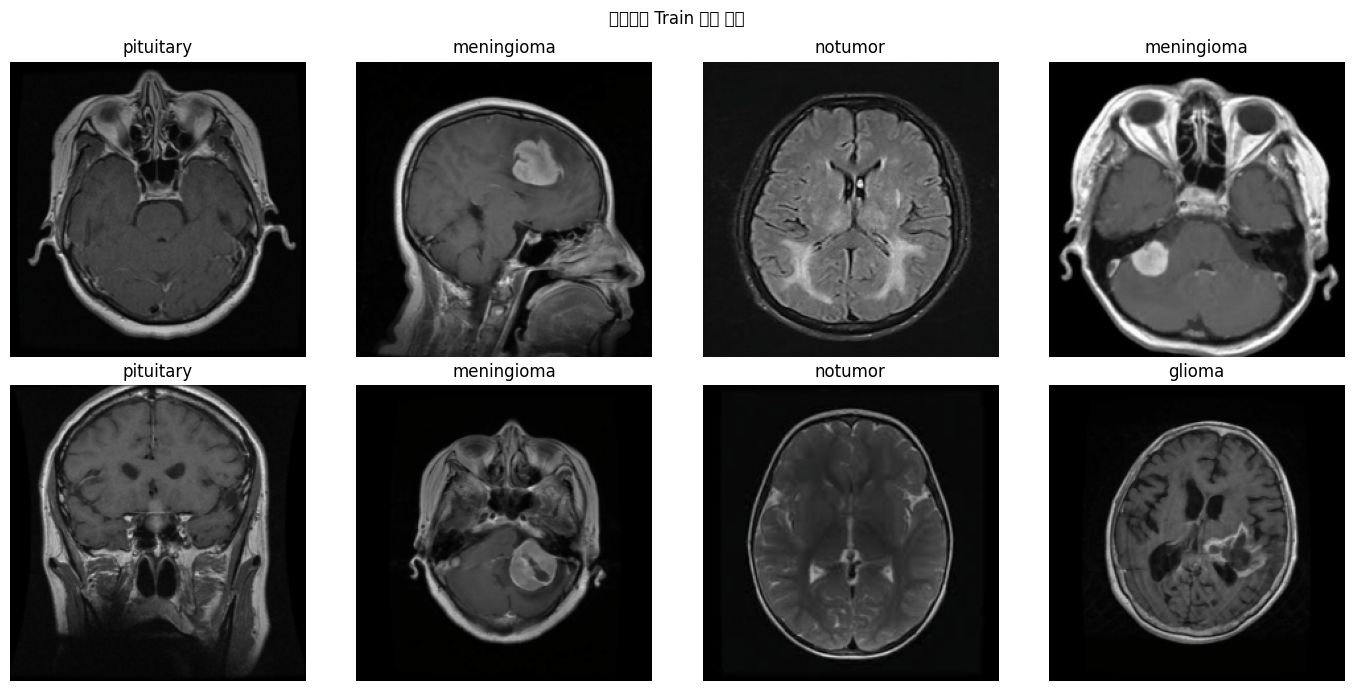

In [ ]:
# 전처리가 제대로 됐는지 배치 1개 뽑아서 육안 확인
CLASSES = full_train_dataset.classes
images, labels = next(iter(train_loader))

print(f"배치 shape: {images.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()) :
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]])
    ax.axis("off")
plt.suptitle("전처리된 Train 배치 샘플")
plt.tight_layout()
plt.show()